In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# Загрузите данные.

In [40]:
df = pd.read_csv('Diabetes.csv')

In [41]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Выведите диаграмму долей объектов, имеющих или нет заболевания диабетом.

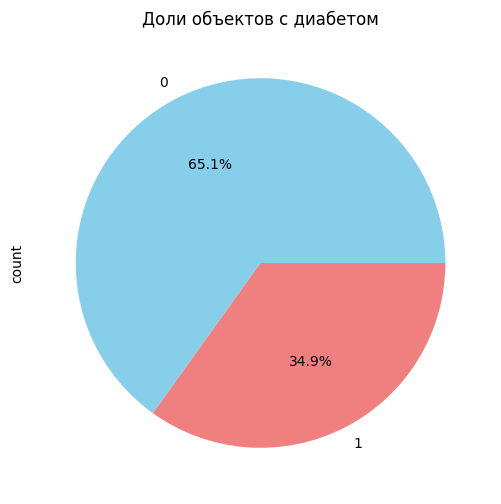

In [42]:
plt.figure(figsize=(6, 6))
df['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Доли объектов с диабетом')
plt.show()

# Выведите гистограммы значений каждого из 8 признаков.

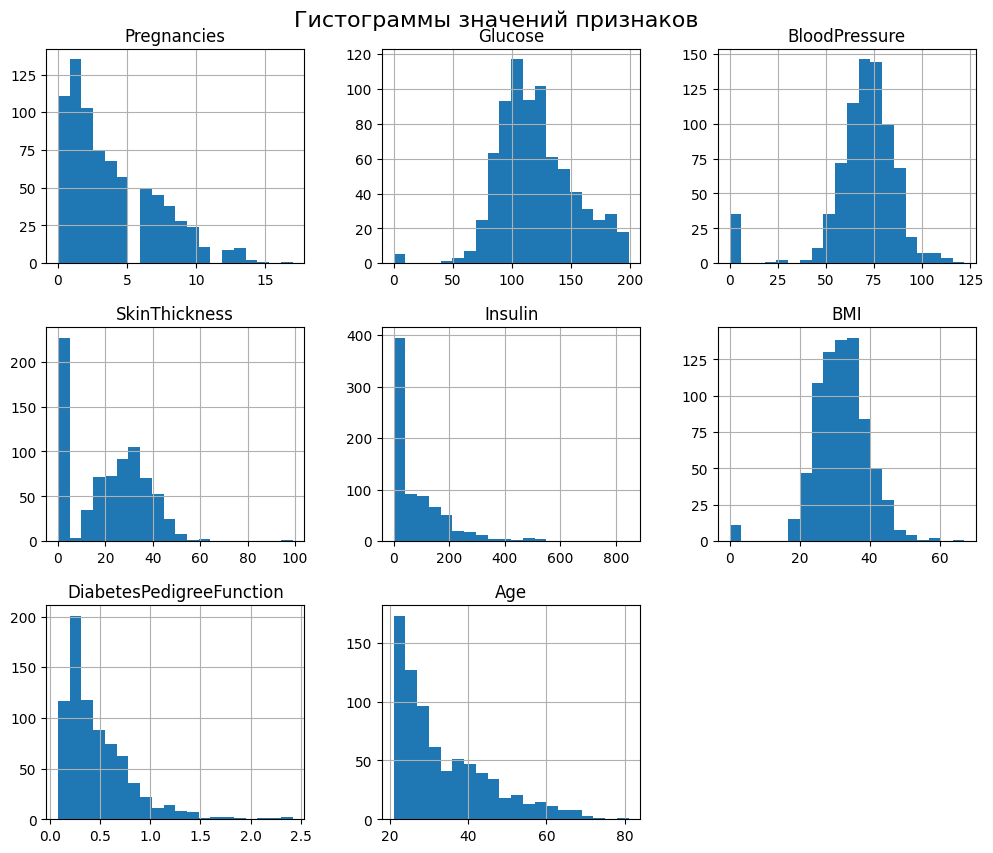

In [43]:
df.drop('Outcome', axis=1).hist(figsize=(12, 10), bins=20)
plt.suptitle('Гистограммы значений признаков', x=0.5, y=0.92, fontsize=16)
plt.show()

# Постройте классификатор типа «Случайный лес» (в любой конфигурации).

In [44]:
y = df['Outcome']
X = df.drop('Outcome', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

Берем реализацию дерева из 8 лабы

In [25]:
class DecisionTreeClassifier:
    def __init__(self, max_depth=None, min_samples_leaf=1, criterion='gini'):
        self.criterion = criterion
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth

    def fit(self, X, y):
        self.n_classes_ = len(set(y))
        self.n_features_ = X.shape[1]
        self.tree_ = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples_per_class = [len(y[y == c]) for c in range(self.n_classes_)]
        predicted_class = max(range(self.n_classes_), key=lambda c: n_samples_per_class[c])

        if self.max_depth is not None and depth >= self.max_depth or \
                all(n == 0 for n in n_samples_per_class) or \
                len(set(y)) == 1 or \
                len(y) <= self.min_samples_leaf:
            return {'class': predicted_class}

        best_split = self._find_best_split(X, y)

        if best_split is None:
            return {'class': predicted_class}

        left_indices, right_indices = best_split['left_indices'], best_split['right_indices']
        left_subtree = self._grow_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self._grow_tree(X[right_indices], y[right_indices], depth + 1)

        return {
            'feature_index': best_split['feature_index'],
            'threshold': best_split['threshold'],
            'left': left_subtree,
            'right': right_subtree
        }

    def _find_best_split(self, X, y):
        if (self.criterion == 'gini'):
            best_split = None
            best_gini = 1.0
            n_samples = len(y)

            for feature_index in range(self.n_features_):
                thresholds = sorted(set(X[:, feature_index]))

                for threshold in thresholds:
                    left_indices = []
                    right_indices = []

                    for i in range(n_samples):
                        if X[i][feature_index] <= threshold:
                            left_indices.append(i)
                        else:
                            right_indices.append(i)

                    if len(left_indices) == 0 or len(right_indices) == 0:
                        continue

                    gini = self._calculate_gini_index(y[left_indices], y[right_indices])
                    if gini < best_gini:
                        best_gini = gini
                        best_split = {
                            'feature_index': feature_index,
                            'threshold': threshold,
                            'left_indices': left_indices,
                            'right_indices': right_indices
                        }

            return best_split
        elif (self.criterion == 'entropy'):
            best_split = None
            best_info_gain = -1

            current_entropy = self._calculate_entropy(y)
            n_samples = len(y)

            for feature_index in range(self.n_features_):
                thresholds = sorted(set(X[:, feature_index]))

                for threshold in thresholds:
                    left_indices = []
                    right_indices = []

                    for i in range(n_samples):
                        if X[i][feature_index] <= threshold:
                            left_indices.append(i)
                        else:
                            right_indices.append(i)

                    if len(left_indices) == 0 or len(right_indices) == 0:
                        continue

                    info_gain = self._calculate_information_gain(y, left_indices, right_indices, current_entropy)
                    if info_gain > best_info_gain:
                        best_info_gain = info_gain
                        best_split = {
                            'feature_index': feature_index,
                            'threshold': threshold,
                            'left_indices': left_indices,
                            'right_indices': right_indices
                        }

            return best_split
            

    def _calculate_gini_index(self, left_y, right_y):
        n_left = len(left_y)
        n_right = len(right_y)
        n_total = n_left + n_right

        gini_left = 1.0 - sum((len(left_y[left_y == c]) / n_left) ** 2 for c in range(self.n_classes_))
        gini_right = 1.0 - sum((len(right_y[right_y == c]) / n_right) ** 2 for c in range(self.n_classes_))

        gini_index = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
        return gini_index
    
    def _calculate_entropy(self, y):
        class_counts = np.bincount(y)
        probabilities = class_counts / len(y)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy

    def _calculate_information_gain(self, y, left_indices, right_indices, current_entropy):
        p_left = len(left_indices) / len(y)
        p_right = len(right_indices) / len(y)

        left_entropy = self._calculate_entropy(y[left_indices])
        right_entropy = self._calculate_entropy(y[right_indices])

        information_gain = current_entropy - (p_left * left_entropy + p_right * right_entropy)
        return information_gain

    def predict(self, X):
        return [self._predict_tree(x, self.tree_) for x in X]

    def _predict_tree(self, x, node):
        if 'class' in node:
            return node['class']

        if x[node['feature_index']] <= node['threshold']:
            return self._predict_tree(x, node['left'])
        else:
            return self._predict_tree(x, node['right'])

In [26]:
class RandomForestClassifier:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_leaf=1, criterion='gini'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        self.trees = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        for _ in range(self.n_estimators):
            tree = DecisionTreeClassifier(max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf, criterion=self.criterion)
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_subset = X[indices]
            y_subset = y[indices]
            tree.fit(X_subset, y_subset)
            self.trees.append(tree)

    def predict(self, X):
        predictions = np.zeros((X.shape[0], len(self.trees)))
        
        for i, tree in enumerate(self.trees):
            predictions[:, i] = tree.predict(X)
        
        return np.round(np.mean(predictions, axis=1))


In [32]:
random_forest = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_leaf=1, criterion='entropy')
random_forest.fit(X_train.values, y_train.values)

# Оцените качество работы классификатора, построив Confusion matrix и вычислив метрик accuracy, рrecision, recall, F1, AUC ROC. 

In [37]:
predictions = random_forest.predict(X_test.values)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")

recall = recall_score(y_test, predictions)
print(f"Recall: {recall}")

precision = precision_score(y_test, predictions)
print(f"Precision: {precision}")

f1 = f1_score(y_test, predictions)
print(f"F1: {f1}")

roc_auc = roc_auc_score(y_test, predictions)
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.7575757575757576
Recall: 0.6625
Precision: 0.6463414634146342
F1: 0.654320987654321
ROC AUC: 0.7352235099337749


# Дополнительные задания

## Избавиться от нулей в признаках, не имеющих нулевых значений по своему смыслу, заменить нули, свидетельствующие об отсутствии данных на медиану ненулевых признаков. С исправленной выборкой повторить пункты 3-5 базового блока и сравните результаты.

In [59]:
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].mean())
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].mean())
df['BMI'] = df['BMI'].replace(0, df['BMI'].mean())

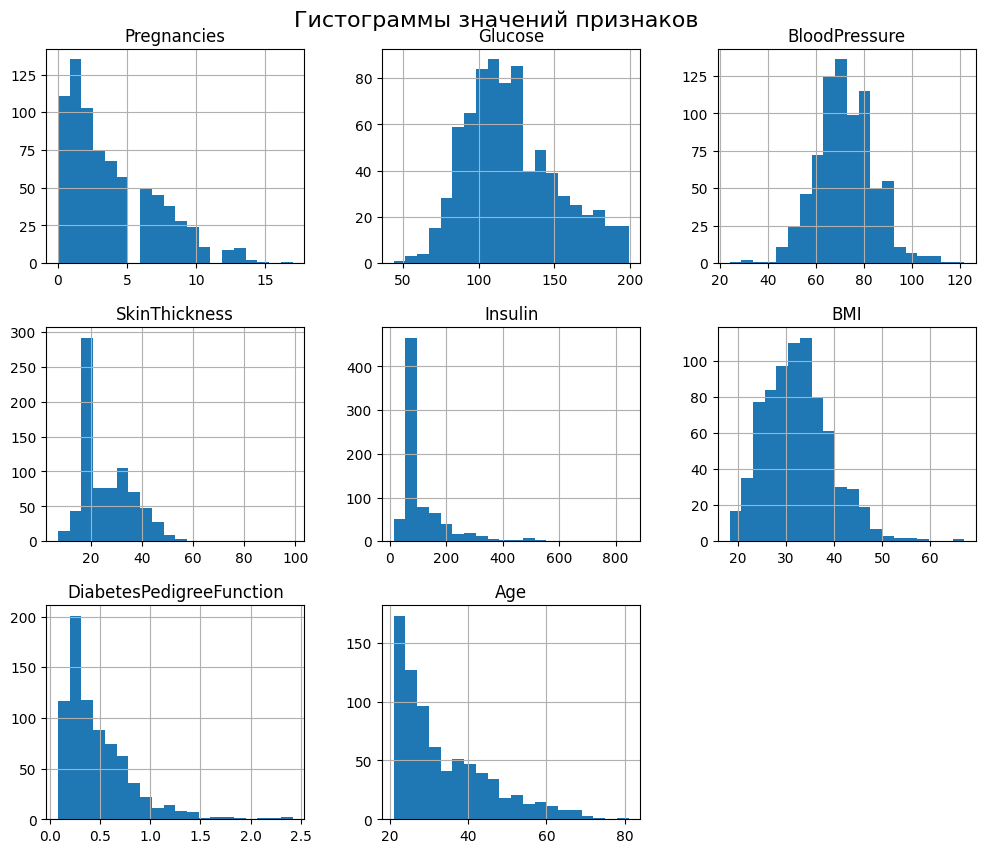

In [60]:
df.drop('Outcome', axis=1).hist(figsize=(12, 10), bins=20)
plt.suptitle('Гистограммы значений признаков', x=0.5, y=0.92, fontsize=16)
plt.show()

In [50]:
y = df['Outcome']
X = df.drop('Outcome', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

random_forest = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_leaf=1, criterion='entropy')
random_forest.fit(X_train.values, y_train.values)

In [51]:
predictions = random_forest.predict(X_test.values)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")

recall = recall_score(y_test, predictions)
print(f"Recall: {recall}")

precision = precision_score(y_test, predictions)
print(f"Precision: {precision}")

f1 = f1_score(y_test, predictions)
print(f"F1: {f1}")

roc_auc = roc_auc_score(y_test, predictions)
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.7662337662337663
Recall: 0.625
Precision: 0.6756756756756757
F1: 0.6493506493506493
ROC AUC: 0.7330298013245033


## Постройте раздельные гистограммы признаков для обоих целевых классов. Оцените вид и параметры распределения значений по каждому из признаков. Обоснуйте значимость/незначимость различия этих параметров для обоих целевых классов.

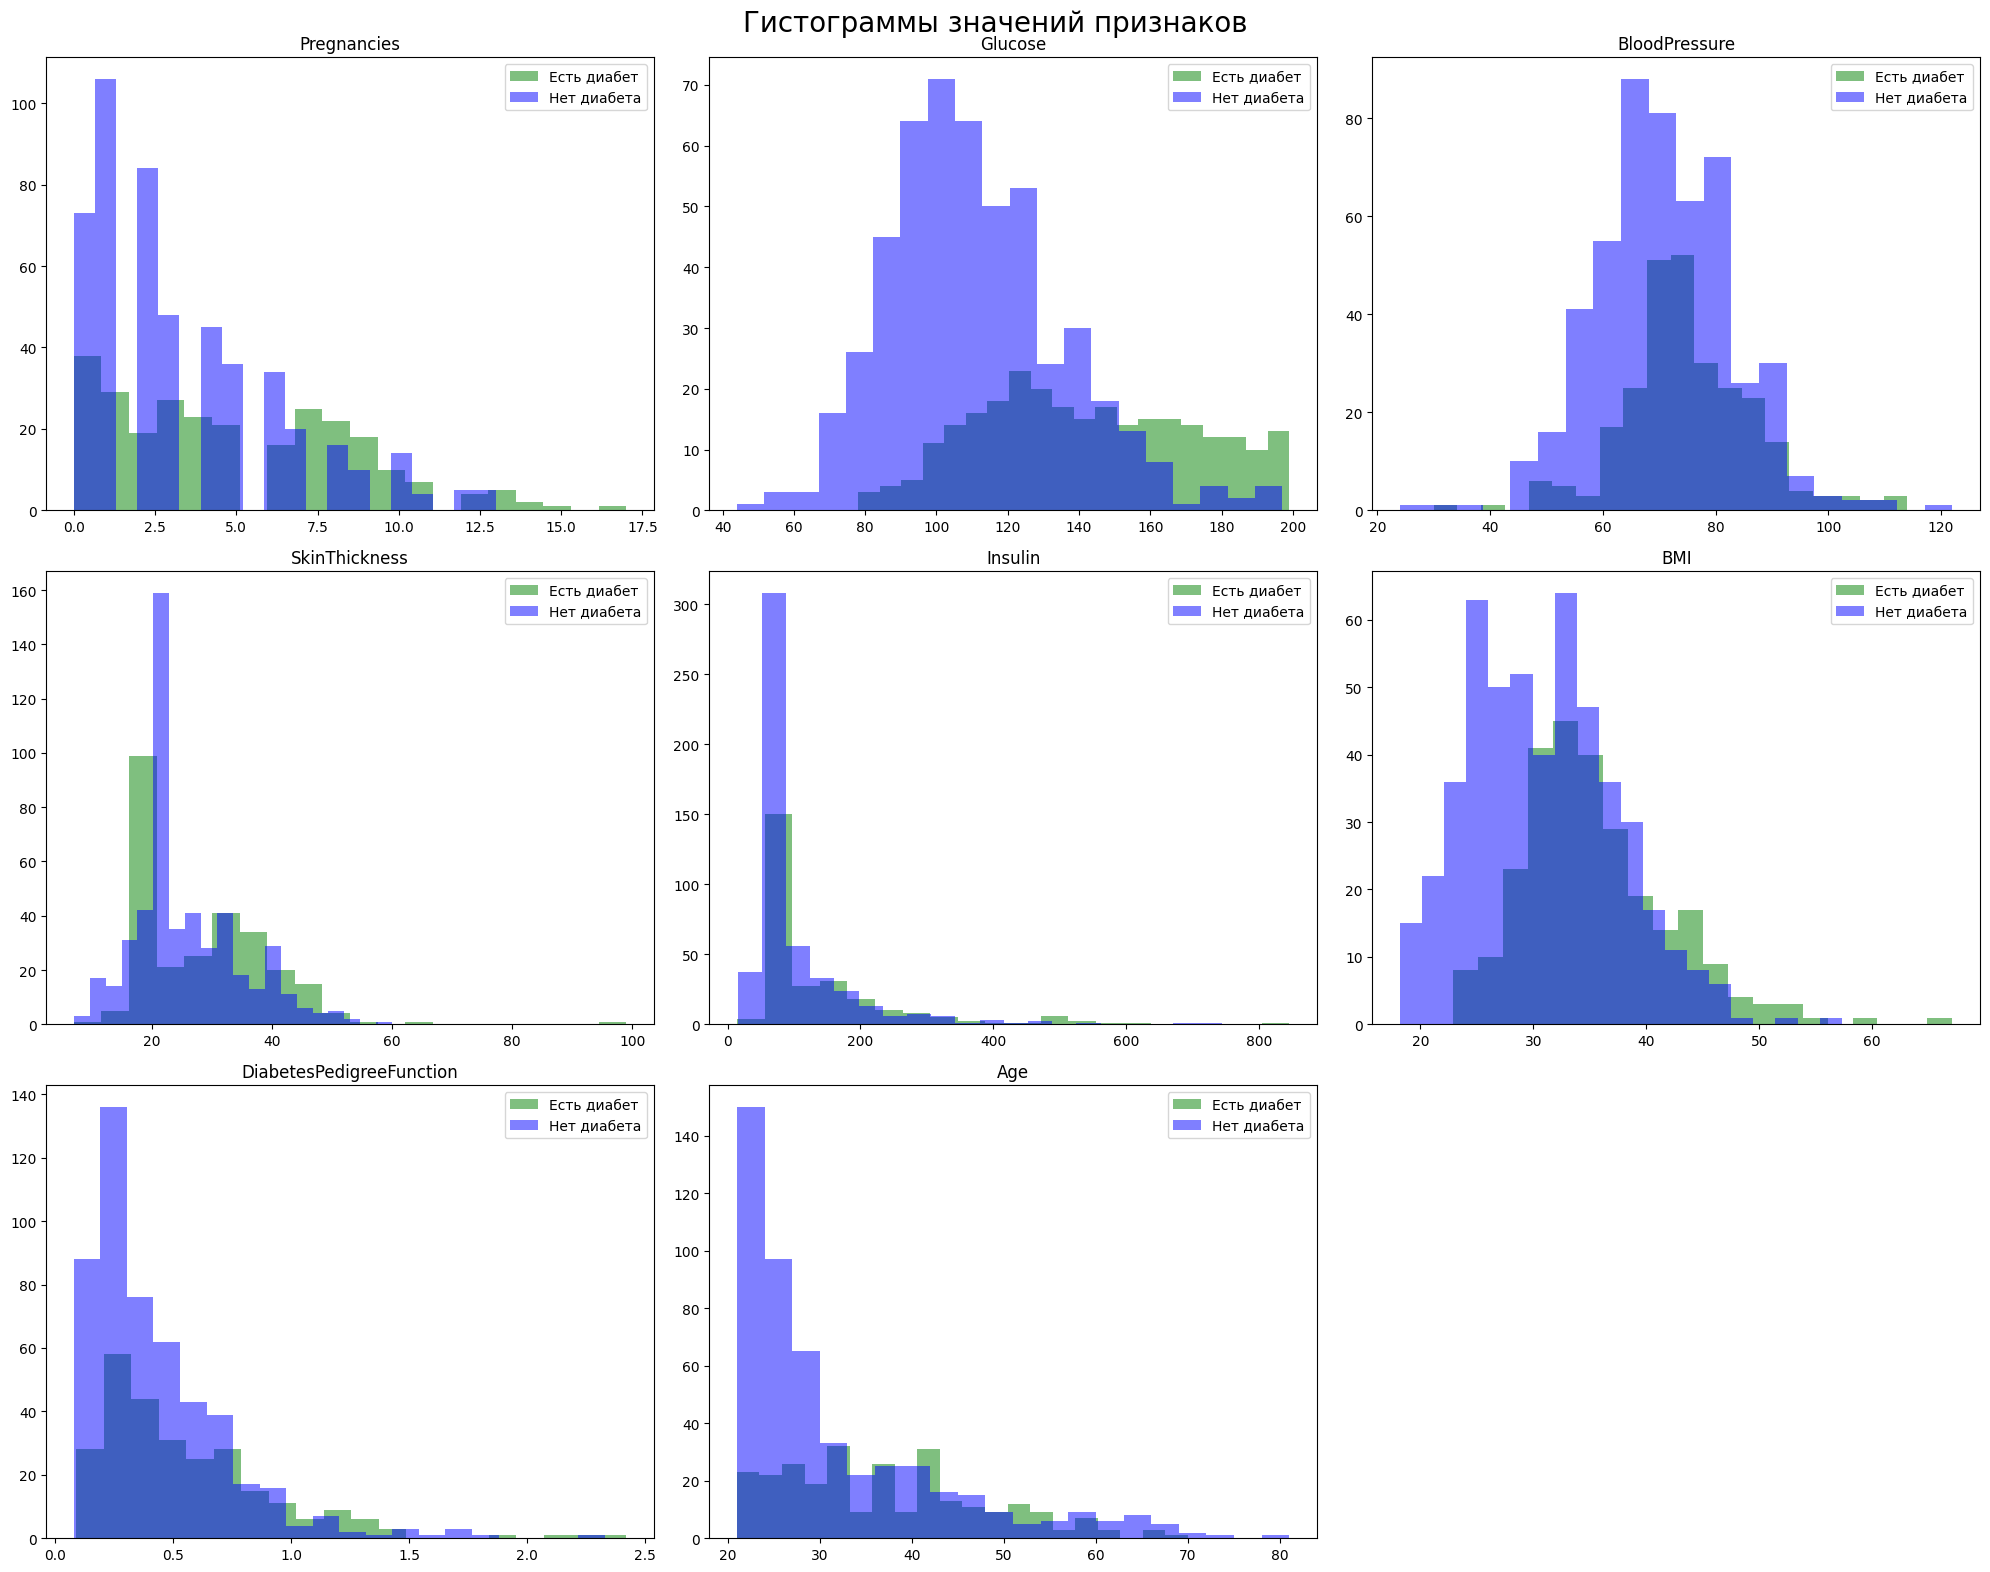

In [61]:
plt.figure(figsize=(20, 16))

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i + 1)
    plt.hist(df[df['Outcome'] == 1][column], bins=20, alpha=0.5, color='green', label='Есть диабет')
    plt.hist(df[df['Outcome'] == 0][column], bins=20, alpha=0.5, color='blue', label='Нет диабета')
    plt.title(column)
    plt.legend()


plt.suptitle('Гистограммы значений признаков', fontsize=20)
plt.tight_layout()
plt.show()